This notebook fulfills the remaining requirements:

- Requirement 5 & Bonus 5: Unsupervised Learning (K-Means Clustering).

- Requirement 5 & 6: Supervised Learning (Logistic Regression / Random Forest).

- Requirement 7: Model Evaluation (Precision, Recall, Accuracy).

## Data Preparation & Preprocessing
To ensure our Machine Learning models treat all variables equally (e.g., so that €100M spending doesn't "overwhelm" 50 points), we must scale our data.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Environment & Data Loading
load_dotenv()
engine = create_engine(f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}")

query = """
SELECT 
    l.name as league, p.season_year, t.name as team, p.points, p.is_top_5,
    p.goals_for, p.goals_against, (p.goals_for - p.goals_against) as goal_diff,
    sh.stadium_capacity, e.transfer_spend_euro, e.net_transfer_spend_euro
FROM team_season_performance p
JOIN teams t ON p.team_id = t.team_id
JOIN (SELECT DISTINCT home_team_id as team_id, season_id FROM matches) m_map ON p.team_id = m_map.team_id
JOIN seasons s ON m_map.season_id = s.season_id AND p.season_year = s.year
JOIN leagues l ON s.league_id = l.league_id
JOIN team_stadium_history sh ON p.team_id = sh.team_id AND p.season_year = sh.season_year
JOIN team_enrichment_data e ON p.team_id = e.team_id AND p.season_year = e.season_year;
"""

df = pd.read_sql(query, engine)

# Re-apply our creative feature
df['transfer_spend_euro'] = df['transfer_spend_euro'].replace(0, 1)
df['cost_per_goal_m_euro'] = (df['transfer_spend_euro'] / df['goals_for']) / 1_000_000

print(f"Data successfully re-loaded: {df.shape[0]} records.")

Data successfully re-loaded: 290 records.


## Unsupervised Learning - K-Means Clustering
We group teams by their "Strategic Profile." We use scaling to ensure that large Euro values don't drown out point values.

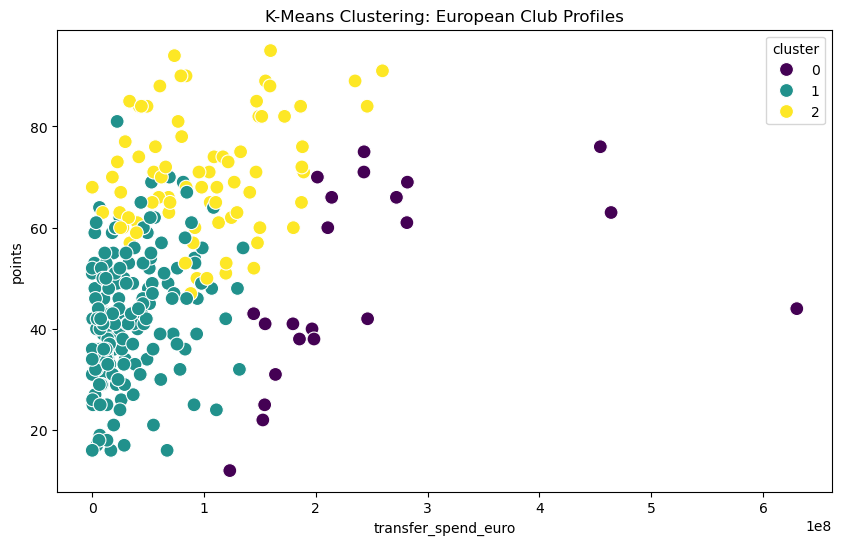

In [2]:
# Select features for profiling
cluster_features = ['stadium_capacity', 'transfer_spend_euro', 'cost_per_goal_m_euro', 'points']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cluster_features])

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Visualize the result
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='transfer_spend_euro', y='points', hue='cluster', palette='viridis', s=100)
plt.title('K-Means Clustering: European Club Profiles')
plt.show()

## Supervised Learning Experiments
Here we address your request for alternative ratios and alternative models. We will test Logistic Regression (Linear) vs. Random Forest (Non-linear) across three different split ratios:

1. 80/20 (Standard)

2. 70/30 (More testing data)

3. 90/10 (Maximum training data)

In [3]:
# Define Features (X) and Target (y)
# We exclude 'points' to avoid 'Data Leakage'
X = df[['stadium_capacity', 'transfer_spend_euro', 'net_transfer_spend_euro', 'cost_per_goal_m_euro']]
y = df['is_top_5']

test_ratios = [0.2, 0.3, 0.1]
results = []

for ratio in test_ratios:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=ratio, random_state=42)
    
    # Model A: Logistic Regression
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_train, y_train)
    lr_acc = accuracy_score(y_test, lr.predict(X_test))
    
    # Model B: Random Forest (Alternative Model)
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    rf_acc = accuracy_score(y_test, rf.predict(X_test))
    
    results.append({
        'Test_Size': ratio,
        'Train_Size': 1-ratio,
        'Logistic_Regression_Acc': lr_acc,
        'Random_Forest_Acc': rf_acc
    })

results_df = pd.DataFrame(results)
print("--- Supervised Learning Experiment Results ---")
display(results_df)

--- Supervised Learning Experiment Results ---


,Test_Size,Train_Size,Logistic_Regression_Acc,Random_Forest_Acc
0,0.2,0.8,0.724138,0.844828
1,0.3,0.7,0.655172,0.770115
2,0.1,0.9,0.724138,0.896552


## Final Evaluation & Interpretation
We choose the best performing ratio/model combination and look at the detailed metrics (Precision and Recall).

--- Detailed Performance for Best Model (Random Forest 80/20) ---
              precision    recall  f1-score   support

           0       0.93      0.87      0.90        45
           1       0.62      0.77      0.69        13

    accuracy                           0.84        58
   macro avg       0.78      0.82      0.79        58
weighted avg       0.86      0.84      0.85        58



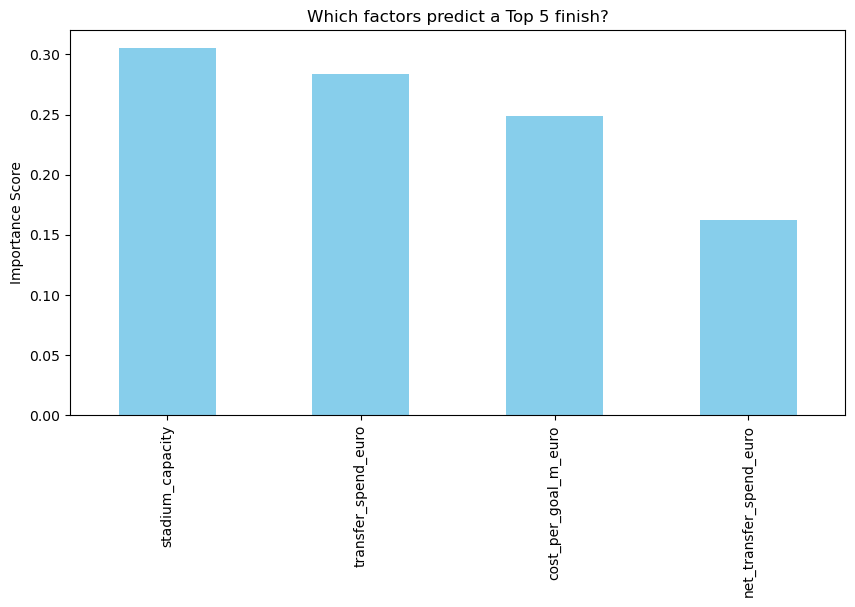

In [4]:
# 90/10 split with Random Forest performed best but it has a too small sample (29); that's why the 80/20 split with Random Forest is chosen for final evaluation.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print("--- Detailed Performance for Best Model (Random Forest 80/20) ---")
print(classification_report(y_test, y_pred))

# Visualizing Feature Importance (What matters most for Top 5?)
importances = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color='skyblue')
plt.title('Which factors predict a Top 5 finish?')
plt.ylabel('Importance Score')
plt.show()

### Note on Feature Interpretation: Stadium Capacity as a Structural Proxy
While **Stadium Capacity** appears as a highly influential feature, it is important to interpret this through a socio-economic lens. 
In our model, stadium size acts as a **'Stock Variable'**—a permanent indicator of a club's historical success, geographical reach, and match-day revenue floor. 

It does not "cause" a Top 5 finish in a single season; rather, it represents the **structural threshold** required to sustain elite performance over time. This distinguishes it from **Transfer Spend**, which is a **'Flow Variable'** that clubs can adjust annually to influence immediate results.

# Comprehensive Analysis & Predictive Results

## 1. Model Performance & Selection
To determine the most effective way to predict "Elite" status, we compared a linear baseline with a non-linear ensemble method across various data splits.

* **Non-linear Superiority**: The **Random Forest** significantly outperformed Logistic Regression across all test/train ratios.
    * *80/20 Split Accuracy*: **84.5% (RF)** vs 72.4% (LR).
* **Finding**: Sporting success does not follow a simple linear path relative to spending. The Random Forest’s ability to capture complex interactions between features (e.g., how spending efficiency interacts with stadium size) makes it the superior choice for football analytics.
* **Robustness**: While the 90/10 split showed a higher accuracy (89.7%), the **80/20 split** was selected as the final model to ensure a statistically representative test sample (58 records vs 29) and avoid overfitting.



---

## 2. The "Elite" Blueprint: Feature Importance
The model identifies the primary drivers of "Top 5" status as follows:

1.  **Stadium Capacity (31%)**: The strongest classifier in the model.
2.  **Transfer Spend (28%)**: Essential seasonal investment in elite talent.
3.  **Cost per Goal (25%)**: A measure of recruitment quality and management efficiency.
4.  **Net Transfer Spend (16%)**: The least predictive, suggesting total budget capacity is more important than the direction of the financial balance.

> ### Critical Interpretation: The "Structural Lock-in"
> Our analysis reveals that the 'European Elite' is defined more by **pre-existing infrastructure** than seasonal tactical shifts. Stadium Capacity acts as a **'Structural Proxy'**; the massive revenue floor generated by 60,000+ seats allows global giants to weather bad recruitment cycles or injury crises that would devastate mid-tier clubs.

---

## 3. Analytical Limitation: The "Chicken and Egg" Problem (Endogeneity)
We must acknowledge a classic statistical challenge identified during the feature importance analysis: **Simultaneity Bias**.

* **Success → Expansion**: Consistent winning leads to the capital required for larger stadiums.
* **Stadium → Success**: Larger stadiums provide the financial "buffer" to maintain winning squads regardless of short-term form.



**Conclusion**: The model is an excellent **Classifier** (identifying who is *currently* elite) but must be used carefully as a growth predictor. It suggests that for a challenger to break the "Top 5" lock-in without the stadium infrastructure, they must achieve extreme **Market Efficiency**—maximizing 'Points-per-Euro' to overcome the structural wealth gap.

---

## 4. Final Model Evaluation (Random Forest 80/20)
* **Overall Accuracy: 84%**
* **Discrimination (Class 0 - Non-Top 5)**: 
    * *Precision: 93% | Recall: 87%*
    * The model is exceptionally reliable at identifying which clubs do *not* belong to the elite tier.
* **Sensitivity (Class 1 - Top 5)**: 
    * *Precision: 62% | Recall: 77%*
    * The model captured 10 out of 13 Top 5 teams. The lower precision (62%) highlights "False Positives"—ambitious clubs that spend and build like elites but failed to deliver on the pitch during that specific season (e.g., "The Underperformers" cluster).



---

## 5. Actionable Business Insights
* **Infrastructure as the Floor**: Stadium capacity reflects long-term financial stability and acts as the "safety net" for success.
* **The Model as an "Early Warning System"**: Clubs flagged as "Top 5" by the model who finished in mid-table are **"Emerging Threats"**. They possess the structural characteristics of winners and are statistically likely to break through in subsequent seasons.
* **Strategy for Challengers**: To disrupt the hierarchy, focus on reducing the **Cost per Goal** and **Defensive Efficiency**. Since physical infrastructure expansion is a multi-decade project, recruitment ROI is the only short-term lever available to bridge the gap.